In [3]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

def find_archive():
    for base in ['E:/archive', '../data/row/archive', '/kaggle/input']:
        if not os.path.exists(base):
            continue
        for root, _, files in os.walk(base):
            if 'Data_Entry_2017.csv' in files:
                return root
    raise FileNotFoundError('Data_Entry_2017.csv not found — set the path manually.')

ARCHIVE = find_archive()
print('archive:', ARCHIVE)

ALL_LABELS = ['Atelectasis','Cardiomegaly','Consolidation','Edema','Effusion','Emphysema',
              'Fibrosis','Hernia','Infiltration','Mass','Nodule','Pleural_Thickening',
              'Pneumonia','Pneumothorax']  

df = pd.read_csv(os.path.join(ARCHIVE, 'Data_Entry_2017.csv'))
print('shape:', df.shape)
df.head(3)

archive: E:/archive
shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


In [4]:
print(f'Images           : {len(df):,}')
print(f'Unique patients  : {df["Patient ID"].nunique():,}')
print(f'Columns          : {list(df.columns)[:8]}')
print(f'Follow-up range  : {df["Follow-up #"].min()} – {df["Follow-up #"].max()}')
# multi-label string -> count of labels per image
df['n_findings'] = df['Finding Labels'].apply(
    lambda s: 0 if s == 'No Finding' else len(s.split('|')))
print(f'Mean labels/image (sick only): {df.loc[df.n_findings>0, "n_findings"].mean():.2f}')

Images           : 112,120
Unique patients  : 30,805
Columns          : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width']
Follow-up range  : 0 – 183
Mean labels/image (sick only): 1.57


## class balance


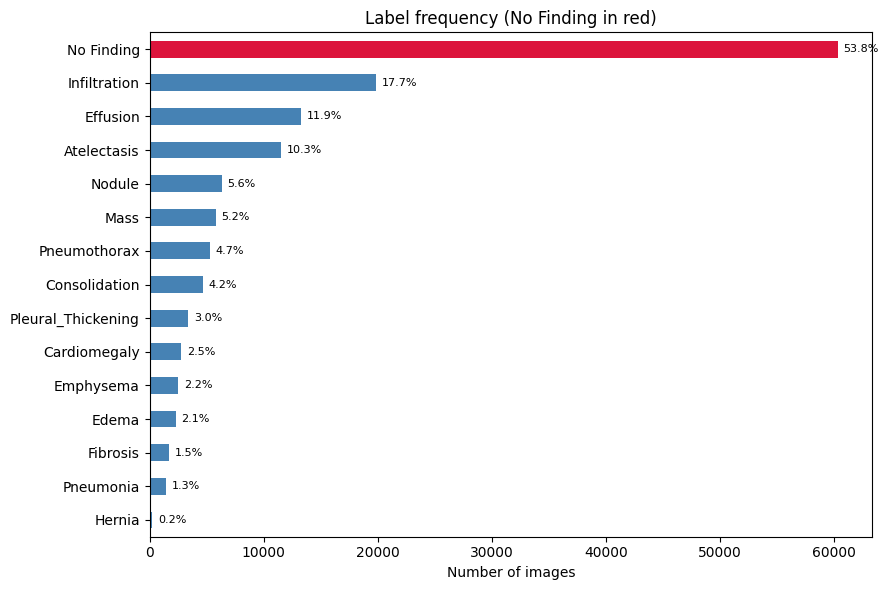

"No Finding" share : 53.8%
Rarest disease     : Hernia at 0.20%


In [5]:
counts = {'No Finding': int((df['Finding Labels'] == 'No Finding').sum())}
for L in ALL_LABELS:
    counts[L] = int(df['Finding Labels'].str.contains(L, regex=False).sum())
counts = pd.Series(counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['crimson' if i == 'No Finding' else 'steelblue' for i in counts.index]
counts.plot.barh(ax=ax, color=colors)
for i, v in enumerate(counts.values):
    ax.text(v + 500, i, f'{v/len(df)*100:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Number of images'); ax.set_title('Label frequency (No Finding in red)')
plt.tight_layout(); plt.show()

print(f'\"No Finding\" share : {counts["No Finding"]/len(df):.1%}')
print(f'Rarest disease     : Hernia at {counts["Hernia"]/len(df):.2%}')

## 3. How many findings co-occur per image?

Most sick images have 1–2 findings, but multi-label is common — which is why the model uses independent sigmoids, not softmax.

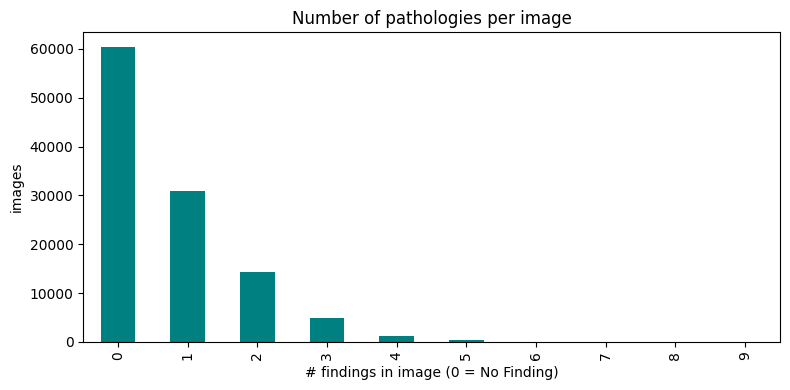

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
df['n_findings'].value_counts().sort_index().plot.bar(ax=ax, color='teal')
ax.set_xlabel('# findings in image (0 = No Finding)'); ax.set_ylabel('images')
ax.set_title('Number of pathologies per image')
plt.tight_layout(); plt.show()

## Clinical features — age, gender, view



Age describe:
min      1.0
25%     35.0
50%     49.0
75%     59.0
max    414.0
Name: Patient Age, dtype: float64

Ages > 100 (impossible): 16 rows


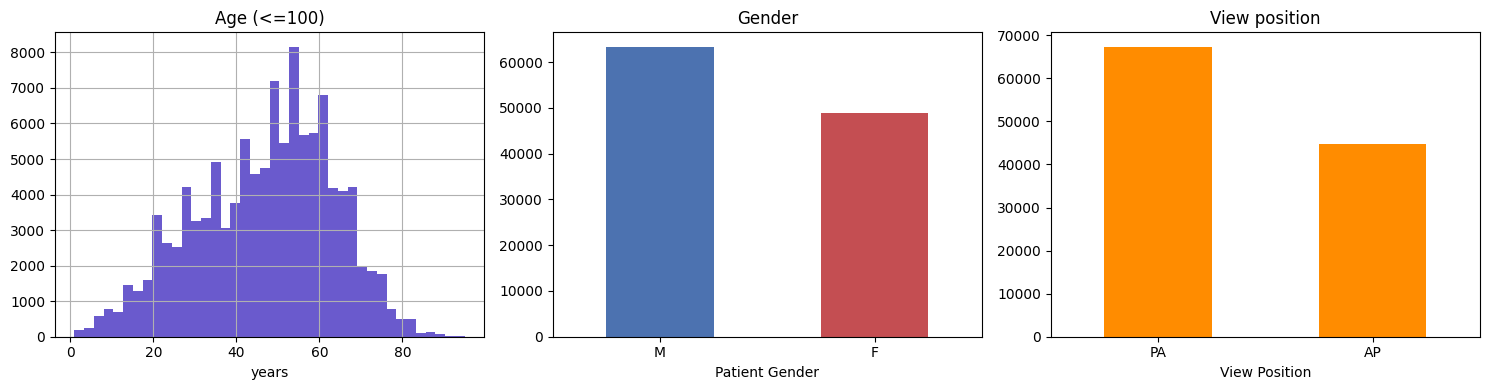

In [8]:
print('Age describe:'); print(df['Patient Age'].describe()[['min','25%','50%','75%','max']])
print(f'\nAges > 100 (impossible): {(df["Patient Age"] > 100).sum()} rows')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df.loc[df['Patient Age'] <= 100, 'Patient Age'].hist(bins=40, ax=ax[0], color='slateblue')
ax[0].set_title('Age (<=100)'); ax[0].set_xlabel('years')
df['Patient Gender'].value_counts().plot.bar(ax=ax[1], color=['#4c72b0','#c44e52'])
ax[1].set_title('Gender'); ax[1].tick_params(axis='x', rotation=0)
df['View Position'].value_counts().plot.bar(ax=ax[2], color='darkorange')
ax[2].set_title('View position'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## Patients vs images (split by patient)

Many patients have multiple scans. A random image split would leak the same patient into train and val so we split **by patient**.

images/patient — mean 3.6, max 184


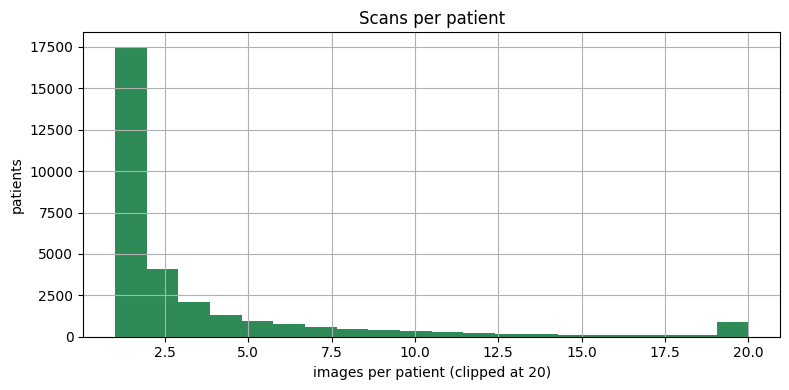

In [9]:
per_patient = df.groupby('Patient ID').size()
print(f'images/patient — mean {per_patient.mean():.1f}, max {per_patient.max()}')
fig, ax = plt.subplots(figsize=(8, 4))
per_patient.clip(upper=20).hist(bins=20, ax=ax, color='seagreen')
ax.set_xlabel('images per patient (clipped at 20)'); ax.set_ylabel('patients')
ax.set_title('Scans per patient'); plt.tight_layout(); plt.show()

## Sample X-rays

indexed 112120 images


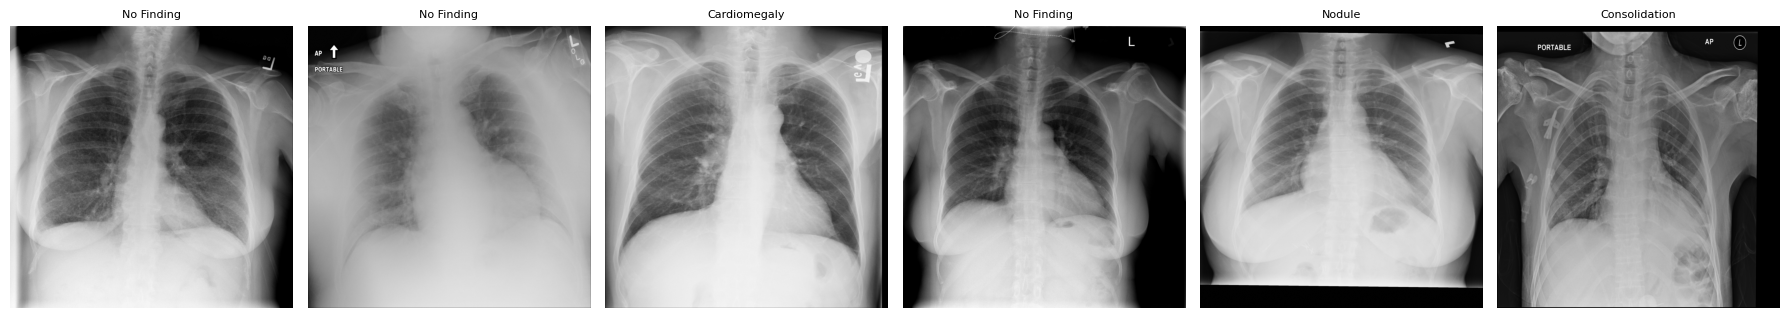

In [10]:
from PIL import Image
# index image files once (handles images_XXX/images/ layout)
idx = {f: os.path.join(d, f) for d, _, fs in os.walk(ARCHIVE) for f in fs if f.endswith('.png')}
print('indexed', len(idx), 'images')

sample = df.sample(6, random_state=0)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, (_, row) in zip(axes, sample.iterrows()):
    p = idx.get(row['Image Index'])
    if p:
        ax.imshow(Image.open(p), cmap='gray')
    ax.set_title(row['Finding Labels'][:22], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()